# Diffuser / collimator angular profiles from the Warwick water scans

Parses the raw goniometer `.out` scans in `/bundle/data/T2K/users/nfost94/water_scans`,
extracts each unit's angular emission profile, compares it against candidate functional forms
(including the profile implicit in `lucid.sources.calibration_sources.generate_laser_photons`),
and produces an averaged "general profile" per device class (diffuser, collimator).

Rig convention (from the raw data, not assumed): both device classes are clamped with their
boresight at `goalTheta ≈ 90°` in the scanner's frame — confirmed by the collimator's periodic
drift-monitor point sitting at exactly `(goalTheta, goalPhi) = (90, 0)`, and by the diffuser
scans peaking symmetrically at `goalTheta ≈ 89–90°` and falling off toward both poles. So the
physically meaningful angle is the separation from each unit's own measured peak, not `goalTheta`
itself.

In [124]:
import re
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.optimize import curve_fit

DATA_DIR = Path('/bundle/data/T2K/users/nfost94/water_scans')
RAW_COLS = ['ts', 'tag', 'iPos', 'goalTheta', 'actualTheta', 'goalPhi', 'actualPhi',
            'op1Power', 'op1PowerSD', 'op1Temp', 'op2Power', 'op2PowerSD', 'op2Temp']


## Parsing

In [125]:
def load_scan(path):
    """Return (meta dict, data DataFrame) for one .out file."""
    lines = Path(path).read_text().splitlines(keepends=True)
    header_lines = [l for l in lines if l.startswith('%')]
    data_lines = [l for l in lines if not l.startswith('%')]

    meta = {}
    for l in header_lines:
        l = l.lstrip('%').strip()
        if ':' in l:
            key, _, val = l.partition(':')
            meta[key.strip()] = val.strip()

    df = pd.read_csv(StringIO(''.join(data_lines)), header=None)
    df.columns = RAW_COLS[:df.shape[1]]
    df['ts'] = pd.to_datetime(df['ts'])
    return meta, df


def parse_axis_range(meta, axis):
    """axis: 'Theta' or 'Phi' -> dict(start, stop, increment, offset)."""
    vals = [float(x) for x in meta[f'Start,Stop,Increment,Offset {axis}'].split(',')]
    return dict(zip(['start', 'stop', 'increment', 'offset'], vals))


## Classifying files and grouping repeats/retakes into one unit

In [126]:
UNIT_RE = re.compile(r'Warwick(Col_C\d+|T\d+|DA\d+)')

def sample_id_of(path):
    # SampleID in the header is the authoritative name; falls back to the filename stem.
    meta, _ = load_scan(path)
    return meta.get('SampleID', Path(path).stem)

def classify(sample_id):
    if re.search(r'Col_C\d+', sample_id):
        return 'collimator'
    if re.search(r'Warwick(T|DA)\d+', sample_id):
        return 'diffuser'
    return 'other'  # e.g. WarwickWA00_bentback -- not a device-class profile, excluded below

def unit_id(sample_id):
    m = UNIT_RE.search(sample_id)
    return f'Warwick{m.group(1)}' if m else sample_id


files = sorted(DATA_DIR.glob('*.out'))
manifest = pd.DataFrame({'path': files})
manifest['sample_id'] = manifest['path'].map(sample_id_of)
manifest['device_type'] = manifest['sample_id'].map(classify)
manifest['unit_id'] = manifest['sample_id'].map(unit_id)
manifest = manifest[manifest.device_type != 'other'].reset_index(drop=True)

# Some units (e.g. WarwickCol_C64) have several files: a first attempt, wavelength-specific
# scans, reproducibility repeats (_repeated_meas_*, _take_out_*). A later scan supersedes an
# earlier one of the same unit, so keep only the most recent file per unit -- filenames are
# 'YYYYMMDD_HHMMSS_...', which sorts chronologically as a string.
manifest['scan_ts'] = manifest['path'].map(lambda p: p.name[:15])
manifest = (manifest.sort_values('scan_ts')
            .groupby('unit_id', as_index=False).tail(1)
            .sort_values(['device_type', 'unit_id']).reset_index(drop=True))

print(manifest.device_type.value_counts())
print(f'{manifest.unit_id.nunique()} distinct units across {len(manifest)} scan files (one file per unit)')


device_type
collimator    69
diffuser      52
Name: count, dtype: int64
121 distinct units across 121 scan files (one file per unit)


## Reducing one scan to a 1D angle-from-boresight profile

**Collimators** have a real 2D structure (a narrow spot in both theta and phi -- confirmed by
`injector_profile_comparison.ipynb`: it's a circular spot, not a band), so their off-boresight
angle needs the true 3D angular separation from a fitted peak `(theta0, phi0)`.

**Diffusers do not** -- the earlier phi-symmetry check (power flat to ~2% across all phi at a
given theta) and `injector_profile_comparison.ipynb`'s own finding ("phi is tiled, not
measured") both say phi carries no real information for this device class. Using the 3D
formula there anyway is a bug, not just an approximation: with the boresight sitting at
`theta0~90`, `cos(alpha) ~ sin(theta)*cos(phi-phi0)` degenerates so that the SAME true
elevation gets mapped to wildly different alpha depending on essentially-noise phi (verified
numerically: true 70 deg off-axis came out anywhere from 78 to 108 deg depending on phi alone).
Diffusers use `alpha = |theta - theta0|` instead, phi-independent, with `theta0` taken from the
peak of the phi-averaged theta profile (robust to the phi noise, unlike a raw top-N-points
pick).

In [127]:
def angular_separation_deg(theta1, phi1, theta2, phi2):
    """Great-circle-style separation between two (theta, phi) directions, in degrees."""
    t1, p1, t2, p2 = map(np.radians, (theta1, phi1, theta2, phi2))
    cos_alpha = np.cos(t1) * np.cos(t2) + np.sin(t1) * np.sin(t2) * np.cos(p1 - p2)
    return np.degrees(np.arccos(np.clip(cos_alpha, -1.0, 1.0)))


def drift_correct(grid, monitor):
    """Divide grid['op1Power'] by the monitor reading interpolated to each grid timestamp,
    normalized to the monitor's own mean (so an idle detector is left unchanged)."""
    if monitor.empty:
        return grid['op1Power'].to_numpy()
    mon = monitor.sort_values('ts')
    t0 = mon['ts'].min()
    mon_t = (mon['ts'] - t0).dt.total_seconds().to_numpy()
    grid_t = (grid['ts'] - t0).dt.total_seconds().to_numpy()
    mon_interp = np.interp(grid_t, mon_t, mon['op1Power'].to_numpy())
    return grid['op1Power'].to_numpy() * mon['op1Power'].mean() / mon_interp


def extract_profile(meta, df, bin_deg, phi_dependent):
    """Return a DataFrame(alpha_deg, mean_power, n) binned in angle-from-peak.

    phi_dependent=True (collimator): true 3D angle from a fitted (theta0, phi0) peak.
    phi_dependent=False (diffuser): phi-independent alpha = |theta - theta0|, theta0 from
    the peak of the phi-averaged theta profile.
    """
    grid = df[df.tag != 9].copy()
    monitor = df[df.tag == 9]

    power = drift_correct(grid, monitor)

    if phi_dependent:
        # peak direction: power-weighted top 1% of points (robust to single-sample noise),
        # circular mean for phi so wrap-around at 0/360 doesn't bias the estimate.
        top = grid.loc[pd.Series(power, index=grid.index).nlargest(max(5, len(grid) // 100)).index]
        theta0 = top['goalTheta'].mean()
        phi0 = np.degrees(np.arctan2(np.sin(np.radians(top['goalPhi'])).mean(),
                                      np.cos(np.radians(top['goalPhi'])).mean()))
        alpha = angular_separation_deg(grid['goalTheta'], grid['goalPhi'], theta0, phi0)
    else:
        theta_profile = pd.Series(power, index=grid.index).groupby(grid['goalTheta']).mean()
        theta0 = theta_profile.idxmax()
        alpha = np.abs(grid['goalTheta'].to_numpy() - theta0)

    # baseline (dark current / stray light): median of the farthest-from-peak 10% of points
    far = alpha >= np.percentile(alpha, 90)
    baseline = np.median(power[far])
    power_bs = np.clip(power - baseline, 0, None)
    peak = power_bs.max()
    if peak <= 0:
        raise ValueError('no signal above baseline')
    norm_power = power_bs / peak

    bins = np.arange(0, alpha.max() + bin_deg, bin_deg)
    binned = (pd.DataFrame({'alpha': alpha, 'norm_power': norm_power})
              .groupby(pd.cut(alpha, bins), observed=True)['norm_power']
              .agg(['mean', 'count']))
    out = pd.DataFrame({
        'alpha_deg': [iv.mid for iv in binned.index],
        'mean_power': binned['mean'].to_numpy(),
        'n': binned['count'].to_numpy(),
    }).dropna()
    return out


## Building per-unit profiles

In [128]:
BIN_DEG = {'diffuser': 1.0, 'collimator': 0.05}

profiles = {}   # (device_type, unit_id) -> list of per-file profile DataFrames
failed = []
for row in manifest.itertuples():
    try:
        meta, df = load_scan(row.path)
        prof = extract_profile(meta, df, BIN_DEG[row.device_type],
                                phi_dependent=(row.device_type == 'collimator'))
        profiles.setdefault((row.device_type, row.unit_id), []).append(prof)
    except Exception as e:
        failed.append((row.path.name, str(e)))

print(f'{len(profiles)} units profiled, {len(failed)} files failed')
for name, err in failed:
    print(f'  FAILED {name}: {err}')


121 units profiled, 0 files failed


## Averaging into one general profile per device class

In [129]:
COMMON_GRID = {
    'diffuser': np.arange(0, 90, 1.0),
    'collimator': np.arange(0, 3, 0.05),
}

def unit_mean_profile(file_profiles, grid):
    """Average repeat/retake/wavelength files for one unit onto a common grid."""
    interp = [np.interp(grid, p['alpha_deg'], p['mean_power'], right=np.nan) for p in file_profiles]
    return np.nanmean(np.vstack(interp), axis=0)

general_profile = {}
unit_profiles_on_grid = {}
for device_type, grid in COMMON_GRID.items():
    units = {uid: fps for (dt, uid), fps in profiles.items() if dt == device_type}
    stacked = np.vstack([unit_mean_profile(fps, grid) for fps in units.values()])
    unit_profiles_on_grid[device_type] = stacked
    general_profile[device_type] = {
        'alpha_deg': grid,
        'mean': np.nanmean(stacked, axis=0),
        'p16': np.nanpercentile(stacked, 16, axis=0),
        'p84': np.nanpercentile(stacked, 84, axis=0),
        'n_units': stacked.shape[0],
    }
    print(f'{device_type}: {stacked.shape[0]} units averaged')


diffuser: 52 units averaged
collimator: 69 units averaged


## Plot: individual units vs the general profile

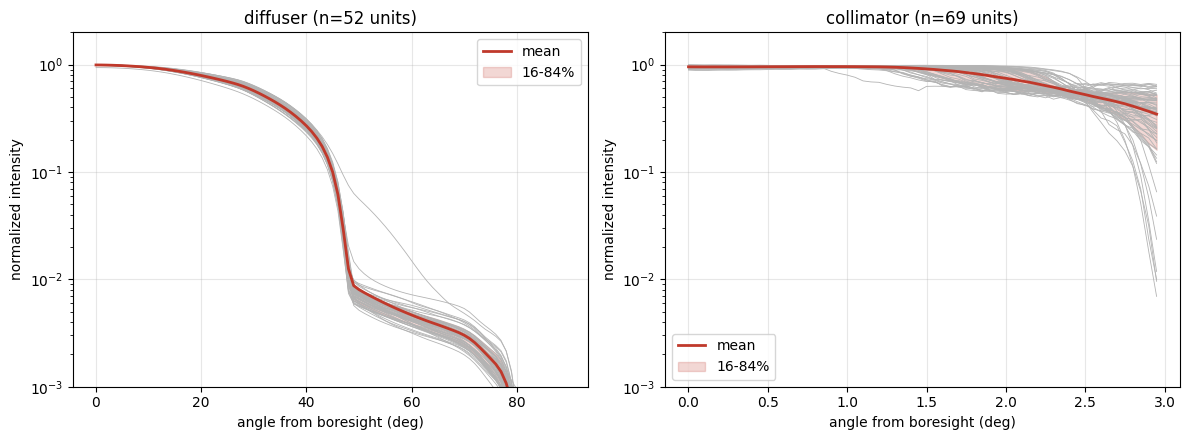

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, device_type in zip(axes, ['diffuser', 'collimator']):
    grid = COMMON_GRID[device_type]
    for row in unit_profiles_on_grid[device_type]:
        ax.plot(grid, row, color='0.7', lw=0.6)
    gp = general_profile[device_type]
    ax.plot(gp['alpha_deg'], gp['mean'], color='#c0392b', lw=2, label='mean')
    ax.fill_between(gp['alpha_deg'], gp['p16'], gp['p84'], color='#c0392b', alpha=.2, label='16-84%')
    ax.set_yscale('log'); ax.set_ylim(1e-3, 2)
    ax.set_xlabel('angle from boresight (deg)'); ax.set_ylabel('normalized intensity')
    ax.set_title(f'{device_type} (n={gp["n_units"]} units)')
    ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()


## Per-unit fits — how much does the shape actually vary device-to-device?

A fit against the pooled/aggregate profile isn't useful here: it answers "what curve
summarizes all units averaged together", not "what does an individual device's profile look
like" — and per the plot above, the collimator units spread widely enough (relative to their
narrow opening) that the two questions have different answers. Fit to every unit's own profile
independently, and look at the spread of the fitted parameters across units.

Collimators use the plain super-Gaussian (`sigma`, `p`) -- empirically the better fit there.
Diffusers use a **composite**: a super-Gaussian core times a soft Fermi/logistic edge at `a0`
(`w`, `p`, `a0`, `s`) -- matching `injector_profile_comparison.ipynb`'s finding that diffusers
have a diffuse scattering core bounded by a real aperture edge. `s` reports how hard that edge
actually is. This is smooth everywhere, unlike a hard `np.where` cutoff, so it fits directly
with `curve_fit` with no grid-search workaround needed.

Below the edge, several units drop into a noisy, largely unfittable floor (photodiode
noise/stray light at <1% of peak) rather than continuing to decay smoothly -- not a real part
of the angular *shape*, and not worth chasing with extra model parameters (an earlier attempt
added an additive floor term for this and it didn't even land on the right level). Instead,
`FIT_FLOOR` simply excludes points below 1% of peak from the fit objective (and from the R²
reported here) for both device classes -- the fit is judged only on the dynamic range that's
actually measurable, and the composite/super-Gaussian shapes stay exactly as before.

In [131]:
FIT_FLOOR = 0.01  # exclude points below 1% of peak: noise-floor tail, not real shape

def super_gaussian(theta_deg, sigma_deg, p):
    return np.exp(-(np.abs(theta_deg) / sigma_deg) ** p)

def super_gaussian_p0(x):
    return [0.3 * x.max(), 2.0]

def super_gaussian_bounds(x):
    return ([1e-3, 0.5], [2 * x.max(), 20])

def composite(alpha_deg, w_deg, p, a0_deg, s_deg):
    """Super-Gaussian core (exp(-(alpha/w)^(2p))) x a soft Fermi/logistic edge at a0.

    Matches how the diffusers are actually built: a diffuse scattering core bounded by a
    real mechanical/geometric aperture edge. s_deg reports how hard that edge really is
    (small s -> a genuinely hard cutoff, larger s -> a gradual falloff). Smooth everywhere,
    unlike a hard np.where cutoff, so it fits directly with curve_fit -- no grid search needed.
    """
    alpha_deg = np.asarray(alpha_deg, dtype=float)
    core = np.exp(-(alpha_deg / max(w_deg, 1e-6)) ** (2 * p))
    edge = 1.0 / (1.0 + np.exp((alpha_deg - a0_deg) / max(s_deg, 1e-6)))
    return core * edge

def composite_p0(x):
    return [0.3 * x.max(), 1.0, 0.55 * x.max(), 2.0]

def composite_bounds(x):
    return ([1.0, 0.3, 0.1 * x.max(), 0.1], [x.max(), 10, 0.99 * x.max(), 20])

def r_squared(y, y_hat):
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot


def fit_super_gaussian_per_unit(units_dict, grid):
    rows = []
    for uid, file_profiles in units_dict.items():
        y = unit_mean_profile(file_profiles, grid)
        mask = np.isfinite(y) & (y >= FIT_FLOOR)
        x_u, y_u = grid[mask], y[mask]
        if x_u.size < 4:
            continue
        try:
            popt, _ = curve_fit(super_gaussian, x_u, y_u, p0=super_gaussian_p0(x_u),
                                 bounds=super_gaussian_bounds(x_u), maxfev=20000)
            r2 = r_squared(y_u, super_gaussian(x_u, *popt))
            rows.append(dict(unit_id=uid, sigma_deg=popt[0], p=popt[1], r2=r2))
        except RuntimeError:
            continue
    return pd.DataFrame(rows)


def fit_composite_per_unit(units_dict, grid):
    rows = []
    for uid, file_profiles in units_dict.items():
        y = unit_mean_profile(file_profiles, grid)
        mask = np.isfinite(y) & (y >= FIT_FLOOR)
        x_u, y_u = grid[mask], y[mask]
        if x_u.size < 8:
            continue
        try:
            popt, _ = curve_fit(composite, x_u, y_u, p0=composite_p0(x_u),
                                 bounds=composite_bounds(x_u), maxfev=20000)
            r2 = r_squared(y_u, composite(x_u, *popt))
            rows.append(dict(unit_id=uid, w_deg=popt[0], p=popt[1], a0_deg=popt[2], s_deg=popt[3],
                              r2=r2))
        except RuntimeError:
            continue
    return pd.DataFrame(rows)


per_unit_fits = {}
for device_type, grid in COMMON_GRID.items():
    units = {uid: fps for (dt, uid), fps in profiles.items() if dt == device_type}
    fit_fn = fit_super_gaussian_per_unit if device_type == 'collimator' else fit_composite_per_unit
    fits = fit_fn(units, grid)
    per_unit_fits[device_type] = fits
    print(f'{device_type}: fit {len(fits)}/{len(units)} units')
    print(fits.drop(columns='unit_id').describe())
    print()


diffuser: fit 52/52 units
           w_deg          p     a0_deg      s_deg         r2
count  52.000000  52.000000  52.000000  52.000000  52.000000
mean   40.209569   1.065138  43.047341   3.219231   0.999007
std     2.900041   0.090070   0.928639   0.562863   0.000637
min    36.722538   0.666777  38.938895   2.575212   0.995300
25%    38.586653   1.036047  42.893941   2.854675   0.998825
50%    39.827264   1.073338  43.235947   3.135280   0.999050
75%    40.953863   1.108029  43.541158   3.346904   0.999380
max    53.811753   1.308649  44.052110   5.159704   0.999742

collimator: fit 69/69 units
       sigma_deg          p         r2
count  69.000000  69.000000  69.000000
mean    2.995787   4.489890   0.932065
std     0.455350   2.978376   0.058125
min     2.565265   0.928435   0.765285
25%     2.692707   2.089808   0.922073
50%     2.835621   3.542049   0.951232
75%     3.170391   5.970857   0.970841
max     4.981380  13.955533   0.991953



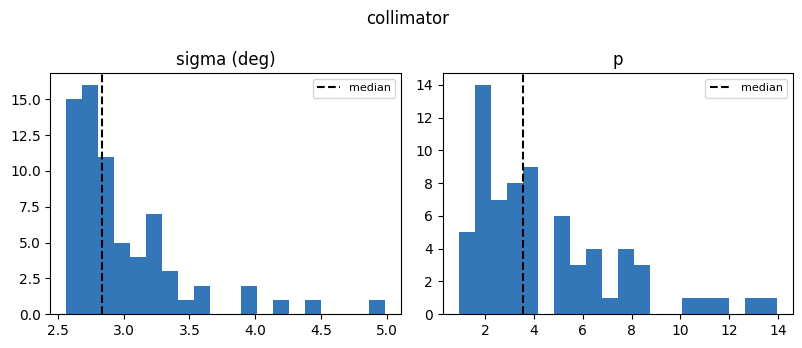

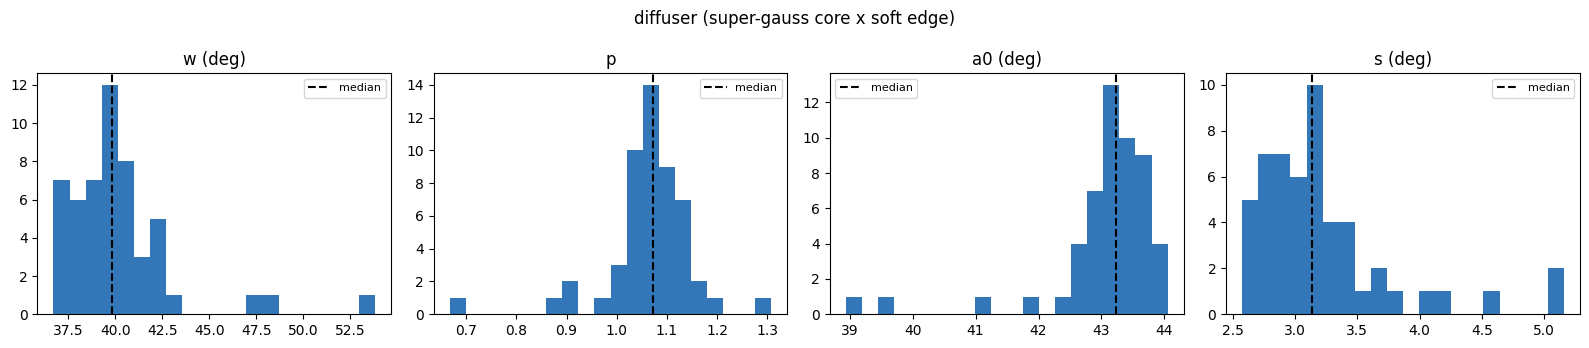

In [132]:
def plot_param_hists(fits, cols, title):
    fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 3.5))
    axes = np.atleast_1d(axes)
    for ax, (col, label) in zip(axes, cols):
        ax.hist(fits[col], bins=20, color='#3477b8')
        ax.axvline(fits[col].median(), color='k', ls='--', lw=1.5, label='median')
        ax.set_title(label); ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout(); plt.show()

plot_param_hists(per_unit_fits['collimator'],
                  [('sigma_deg', 'sigma (deg)'), ('p', 'p')], 'collimator')
plot_param_hists(per_unit_fits['diffuser'],
                  [('w_deg', 'w (deg)'), ('p', 'p'), ('a0_deg', 'a0 (deg)'), ('s_deg', 's (deg)')],
                  'diffuser (super-gauss core x soft edge)')


## Browsing individual fits (worst -> best)

A slider per device class, ranked by fit R² so you can scroll from the worst fits to the best
and see what's actually going wrong (or right) for a given unit -- not just the aggregate
histograms above.

In [133]:
def fit_browser(device_type):
    grid = COMMON_GRID[device_type]
    fits = per_unit_fits[device_type].sort_values('r2').reset_index(drop=True)
    model_fn = super_gaussian if device_type == 'collimator' else composite
    param_cols = ['sigma_deg', 'p'] if device_type == 'collimator' else ['w_deg', 'p', 'a0_deg', 's_deg']

    def plot_rank(rank):
        row = fits.iloc[rank]
        uid = row['unit_id']
        y = unit_mean_profile(profiles[(device_type, uid)], grid)
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(grid, y, 'o', ms=3, color='0.3', label='data')
        ax.plot(grid, model_fn(grid, *row[param_cols]), color='#c0392b', lw=2, label='fit')
        ax.axhline(FIT_FLOOR, color='k', lw=.8, ls=':', label='FIT_FLOOR (excluded below)')
        ax.set_yscale('log'); ax.set_ylim(1e-3, 2)
        ax.set_xlabel('angle from boresight (deg)'); ax.set_ylabel('normalized intensity')
        ax.set_title(f'{device_type} {uid}  (rank {rank + 1}/{len(fits)} by R\u00b2, R\u00b2={row.r2:.3f})')
        ax.legend(); ax.grid(alpha=.3)
        plt.show()

    widgets.interact(plot_rank, rank=widgets.IntSlider(
        min=0, max=len(fits) - 1, step=1, description='worst -> best', continuous_update=False))

fit_browser('diffuser')
fit_browser('collimator')


interactive(children=(IntSlider(value=0, continuous_update=False, description='worst -> best', max=51), Output…

interactive(children=(IntSlider(value=0, continuous_update=False, description='worst -> best', max=68), Output…

## Saving the general profile for use in sim

Saves both: the pooled-mean curve (`*_general_profile.npz`, for plotting/reference) and the
per-unit fit table (`*_{diffuser,collimator}_per_unit.csv`), which is the actual "general
profile" to use in sim — the per-unit median parameters.

The two device classes don't carry the same confidence, and the summary should say so rather
than reporting a bare number for both: diffuser per-unit fits collapse tight (narrow
`w`/`p`/`a0`/`s` spread across units -- one function represents the population well).
Collimator `sigma`/`p` spread much more -- expected, since a fixed absolute alignment/mounting
tolerance is a much bigger fraction of a ~1-3 deg beam than a ~40-90 deg diffuser cone, and
practically less costly, since it's the low-intensity tail of an already-narrow beam that
disagrees most. The IQR alongside the median makes that visible wherever this profile gets
used downstream, instead of silently treating both classes as equally well-determined.

In [134]:
OUT_DIR = Path('.')
for device_type, gp in general_profile.items():
    out_path = OUT_DIR / f'{device_type}_general_profile.npz'
    np.savez(out_path, alpha_deg=gp['alpha_deg'], mean=gp['mean'], p16=gp['p16'], p84=gp['p84'])
    print(f'wrote {out_path}')

    fits = per_unit_fits[device_type]
    csv_path = OUT_DIR / f'{device_type}_per_unit.csv'
    fits.to_csv(csv_path, index=False)
    print(f'wrote {csv_path}')

    stats = fits.drop(columns=['unit_id', 'r2'])
    q1, med, q3 = stats.quantile(.25), stats.median(), stats.quantile(.75)
    print(f'{device_type} recommended (per-unit median [IQR]):')
    for k in stats.columns:
        print(f'  {k:10s} {med[k]:.3f}  [{q1[k]:.3f}, {q3[k]:.3f}]')


wrote diffuser_general_profile.npz
wrote diffuser_per_unit.csv
diffuser recommended (per-unit median [IQR]):
  w_deg      39.827  [38.587, 40.954]
  p          1.073  [1.036, 1.108]
  a0_deg     43.236  [42.894, 43.541]
  s_deg      3.135  [2.855, 3.347]
wrote collimator_general_profile.npz
wrote collimator_per_unit.csv
collimator recommended (per-unit median [IQR]):
  sigma_deg  2.836  [2.693, 3.170]
  p          3.542  [2.090, 5.971]
